# Author: Gianfranco Cisneros

# PID: 6287481

# 0. Imports and Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# 1. Data Preprocessing

## 1.1 EDA and Data Cleaning

Shape of dataset: (403, 6)

Data Types:
 student_id           int64
hours_studied      float64
sleep_hours        float64
attendance_rate    float64
prev_exam_score    float64
lucky_number         int64
dtype: object


,student_id,hours_studied,sleep_hours,attendance_rate,prev_exam_score,lucky_number
count,403.000000,403.000000,391.000000,392.000000,391.000000,403.000000
mean,202.000000,6.317122,6.401790,74.806888,64.441176,49.759305
std,116.480327,2.548540,1.626833,15.752901,16.206720,28.533198
min,1.000000,1.000000,-2.000000,40.000000,30.000000,1.000000
25%,101.500000,4.500000,5.400000,63.900000,53.550000,26.000000
50%,202.000000,6.600000,6.600000,77.400000,65.300000,51.000000
75%,302.500000,8.100000,7.500000,84.925000,75.700000,73.000000
max,403.000000,12.000000,10.000000,150.000000,95.000000,99.000000



Missing Values:
 student_id          0
hours_studied       0
sleep_hours        12
attendance_rate    11
prev_exam_score    12
lucky_number        0
dtype: int64

Duplicate Rows: 0


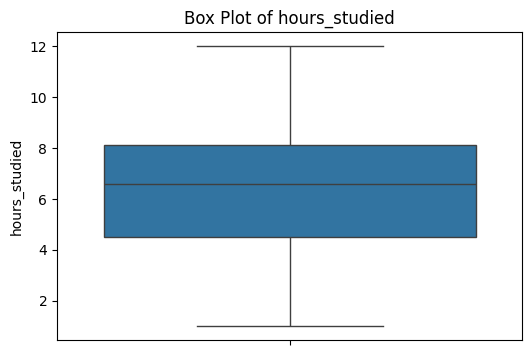

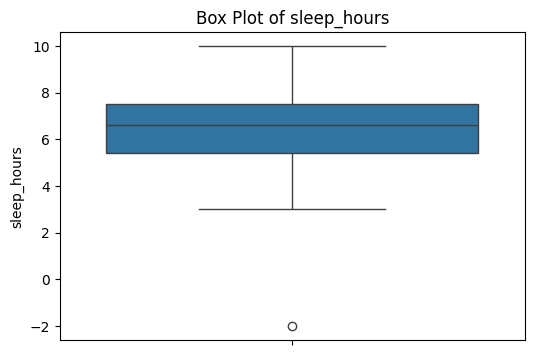

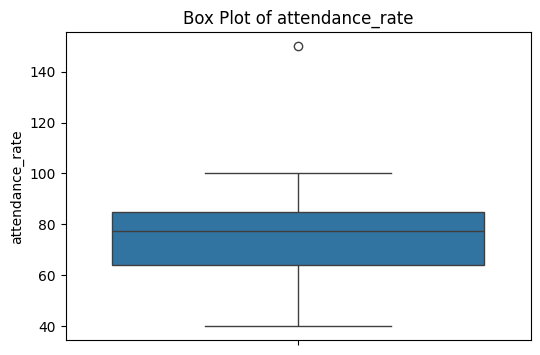

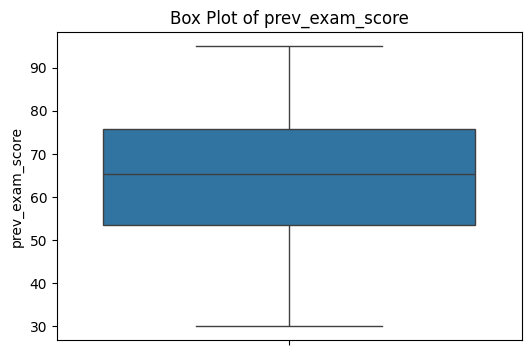

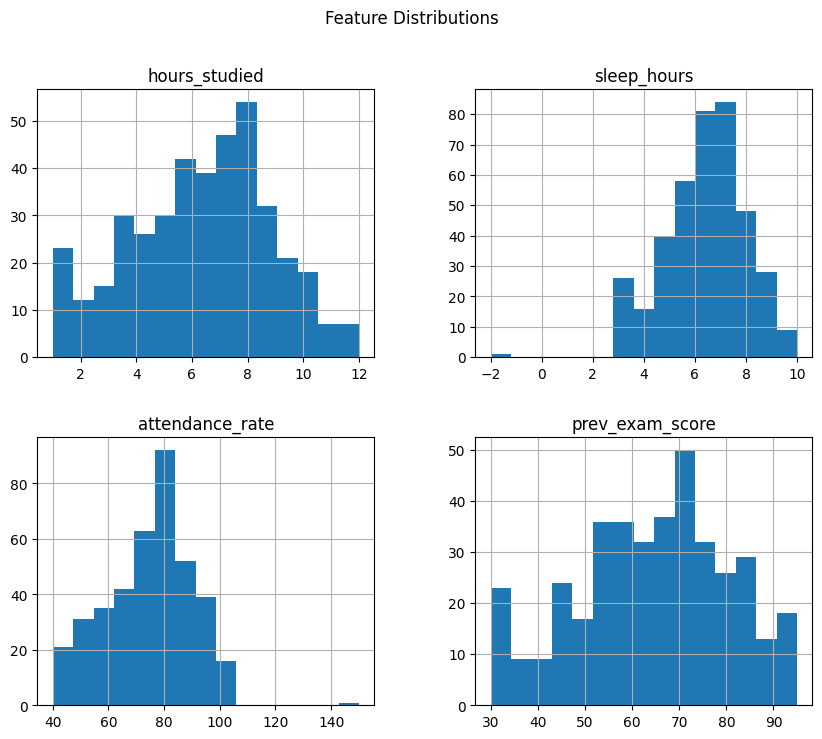


Row Count Before Dropping Rows:  student_id         403
hours_studied      403
sleep_hours        391
attendance_rate    392
prev_exam_score    391
lucky_number       403
dtype: int64

Rows after dropping Duplicates:  student_id         403
hours_studied      403
sleep_hours        391
attendance_rate    392
prev_exam_score    391
lucky_number       403
dtype: int64

Median Values for Data Imputation:
 student_id         202.0
hours_studied        6.6
sleep_hours          6.6
attendance_rate     77.4
prev_exam_score     65.3
lucky_number        51.0
dtype: float64

Impossible Values:


Hours Studied < 0:
 Empty DataFrame
Columns: [student_id, hours_studied, sleep_hours, attendance_rate, prev_exam_score, lucky_number]
Index: []

Sleep Hours < 0:
      student_id  hours_studied  sleep_hours  attendance_rate  prev_exam_score  \
361         362            5.1         -2.0             55.2             52.8   

     lucky_number  
361            95  

Attendance Rate < 0 or > 100:
      stu

In [2]:
# Load data
train = pd.read_csv('p3_students_unlabeled.csv')
test = pd.read_csv('p3_ground_truth.csv')

# Print some basic statistics
print("Shape of dataset:", train.shape)
print("\nData Types:\n", train.dtypes)
display(train.describe())

#Check for missing and duplicate values
print("\nMissing Values:\n", train.isnull().sum())
print("\nDuplicate Rows:", train.duplicated().sum())

# Creates box plots to visualize data and check for outliers or impossible values
features = ['hours_studied', 'sleep_hours', 'attendance_rate', 'prev_exam_score']
for i, col in enumerate(features):
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=train[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()


train[features].hist(bins=15, figsize=(10, 8))
plt.suptitle('Feature Distributions')
plt.show()


print("\nRow Count Before Dropping Rows: ", train.count())

# Drops rows with duplicate values
train = train.drop_duplicates()
print("\nRows after dropping Duplicates: ", train.count())

# Data Imputation for rows with missing values
# The mean will be used since the data has near-normal distribution
train_median = train.median()
print("\nMedian Values for Data Imputation:\n", train_median)
train = train.fillna(train_median)

# Checks for rows with impossible values
print("\nImpossible Values:\n")
print("\nHours Studied < 0:\n", train[train['hours_studied'] < 0])
print("\nSleep Hours < 0:\n", train[train['sleep_hours'] < 0])
print("\nAttendance Rate < 0 or > 100:\n", train[(train['attendance_rate'] < 0) | (train['attendance_rate'] > 100)])
print("\nPrevious Exam Score < 0 or > 100:\n", train[(train['prev_exam_score'] < 0) | (train['prev_exam_score'] > 100)])


# Drops rows with impossible values
# Mostly outliers
train = train[(train['hours_studied'] >= 0) & (train['sleep_hours'] >= 0) & 
                (train['attendance_rate'] >= 0) & (train['attendance_rate'] <= 100) & 
                (train['prev_exam_score'] >= 0) & (train['prev_exam_score'] <= 100)]
print("\nRow Count After Dropping Rows:", train.count())



Quality: 
I decided to use data imputation to fill rows with missing values. This decision was reached because of the number of rows that would have been dropped otherwise, which would have been around 50 rows. In addition, the mean was used to replace the missing data since the data has near-normal distribution, as showed by the graphs. The rows with impossible values were dropped, as they represent rows with outliers, and are therefore, dropped. EDA differs from supervised learning because there is no exam_score to compare the features to, meaning the majority of the EDA was done to clean the data in relation to logical values.

## 1.2 Feature Selection and Normalization

The code below will select the features and normalize the data.

In [3]:
selected_features = ['hours_studied', 'sleep_hours', 'attendance_rate', 'prev_exam_score']
x = train[selected_features]
#y = train['passed']

#x_test = test[selected_features]
#y_test = test['passed']

# Calculate Z-Score for train

scaler = StandardScaler()
normalized_x = scaler.fit_transform(train)

#train_zscore = (train[selected_features] - train[selected_features].mean()) / train[selected_features].std()



Quality:
Normalization is critical for distance-based clustering algorithms because the information that we are trying to train it on is on direction instead of exact volume. If the scales were different from each other, it would result in the model skewing towards a specific feature. 

# 2. K-Means Clustering

## 2.1 NumPy Implementation (From Scratch)

The code below will implement K-Means clustering using NumPy.


Final Centroid Coordinates (Normalized): 
[[ 0.05309976  0.52645496  0.47269513  0.55909833  0.49972674 -0.01800762]
 [-0.07517134 -0.74528262 -0.66917685 -0.79149463 -0.70744448  0.02549272]]

Number of students in each cluster:
Cluster 0: 235 students
Cluster 1: 166 students


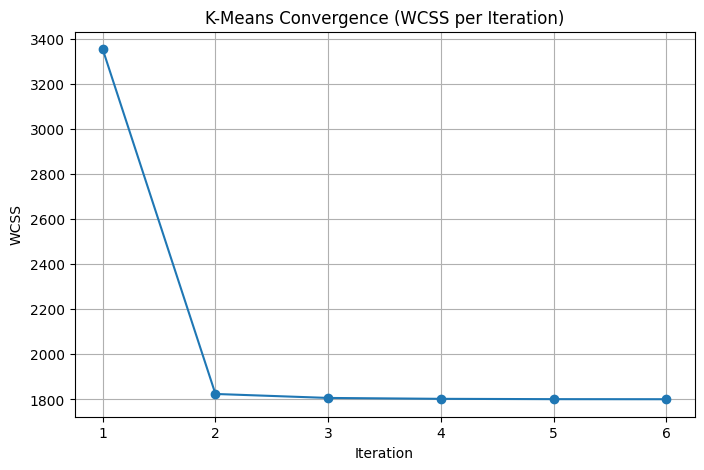

In [4]:
def kmeans_numpy(X, k, max_iterations=100, random_state=67):
    # Converts the train data into a NumPy array
    X = np.array(X)
    # Random number generator
    rng = np.random.RandomState(random_state)
    # Initialize centroids randomly
    initial_indices = rng.permutation(X.shape[0])[:k]
    centroids = X[initial_indices]
    wcss_results = []
    labels = np.zeros(X.shape[0])

    for iteration in range(max_iterations):
        # Assignment Step
        distances = np.zeros((X.shape[0], k))
        for i in range(k):
            # Calculate Euclidean distances
            distances[:, i] = np.linalg.norm(X - centroids[i], axis=1)

        labels = np.argmin(distances, axis=1)

        #Calculate WCSS
        wcss = 0
        for i in range(k):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                wcss += np.sum((cluster_points - centroids[i]) **2)
        wcss_results.append(wcss)

        # Update Step
        new_centroids = np.zeros((k, X.shape[1]))
        for i in range(k):
            cluster_points = X[labels == i]
            # Handles empty clusters
            if len(cluster_points) == 0:
                # If empty, replace with random data point
                new_centroids[i] = X[rng.choice(X.shape[0])]
            else:
                new_centroids[i] = np.mean(cluster_points, axis=0)
        
        # Check for convergence
        if np.all(centroids == new_centroids):
            break
        
        centroids = new_centroids
    
    return centroids, labels, wcss_results

#normalized_x = train_zscore.values
k = 2
centroids, kmeans_labels, wcss_results = kmeans_numpy(normalized_x, k=k, random_state=67)

# Print results
print("\nFinal Centroid Coordinates (Normalized): ")
print(centroids)

# Print number of students in each cluster
kmeans_unique, kmeans_counts = np.unique(kmeans_labels, return_counts=True)
cluster_counts = dict(zip(kmeans_unique, kmeans_counts))
print("\nNumber of students in each cluster:")
for cluster_id, count in cluster_counts.items():
    print(f"Cluster {cluster_id}: {count} students")

# Plot the WCSS across iterations to show convergence
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(wcss_results) + 1), wcss_results, marker='o', linestyle='-')
plt.title('K-Means Convergence (WCSS per Iteration)')
plt.xlabel('Iteration')
plt.ylabel('WCSS')
plt.xticks(range(1, len(wcss_results) + 1))
plt.grid(True)
plt.show()





Quality:
Cluster 0 represents students who are performed well in each category and are above average, since all the z-scores are positive. Cluster 1 represents students who performed poorly in each category, since all the z-scores are negative. Changing the random seed resulted in different but consistent results each time. The purpose of the random seed is to ensure the reproducability of results.

## 2.2 sklearn Verification

Now K Means will be implemented using the sklearn library

In [5]:
# Train K Means
sklearn_kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
sklearn_kmeans.fit(normalized_x)

sklearn_centroids = sklearn_kmeans.cluster_centers_
sklearn_labels = sklearn_kmeans.labels_

# Print results
print("\nSklearn Centroids (Normalized):", sklearn_centroids)
print("\nNumpy Centroids: ", centroids)

# Compare clusters
diff_alignment_1 = np.sum(sklearn_labels != sklearn_labels)
diff_alignment_2 = np.sum(sklearn_labels != (1 - sklearn_labels))
actual_differences = min(diff_alignment_1, diff_alignment_2)
print(f"\nNumber of students assigned differently: {actual_differences}")



Sklearn Centroids (Normalized): [[-0.08097622 -0.73735886 -0.66645905 -0.78315479 -0.71159905  0.02666018]
 [ 0.05779072  0.52623474  0.4756353   0.55891816  0.5078506  -0.01902671]]

Numpy Centroids:  [[ 0.05309976  0.52645496  0.47269513  0.55909833  0.49972674 -0.01800762]
 [-0.07517134 -0.74528262 -0.66917685 -0.79149463 -0.70744448  0.02549272]]

Number of students assigned differently: 0


Quality:
A small difference that exists between the numpy implementation and sklearn implementation is that the clusters are flipped, meaning that cluster 0 for the numpy implementation is cluster 1 for the sklearn implementation. In addition, the n_init=10 could be reason for the flipped clusters. While the numpy implementation only uses 6 iterations, the sklearn implementation runs 10. 

## 2.3 Elbow Method

The code below will use the elbow method to implement K Means

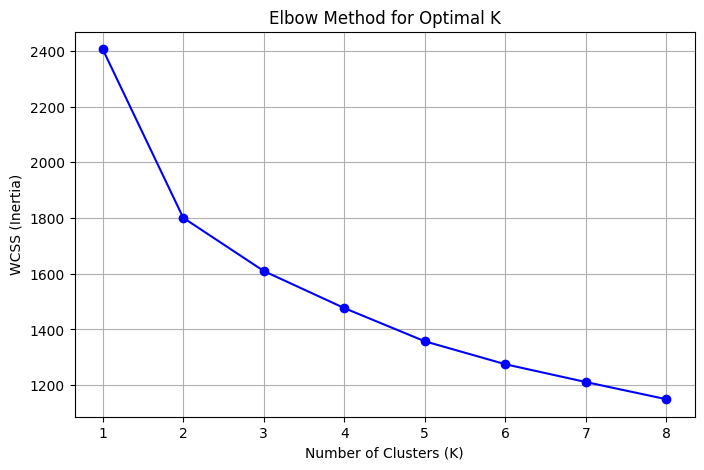

The optimal number of clusters appears to be K = 2


In [6]:
wcss_results = []
k_range = range(1, 9)

# Run K means for each K
# Store WCSS
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(normalized_x)
    wcss_results.append(kmeans.inertia_)

# Plot Curve
plt.figure(figsize=(8,5))
plt.plot(k_range, wcss_results, marker='o', linestyle='-', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

print("The optimal number of clusters appears to be K = 2")

Quality: 
The WCSS always decreases as K increases because the number of clusters increases, meaning that each cluster has a much tighter groups that are more unique. This uniqueness results in less errors, meaning a smaller WCSS. An increasing amount K could also lead to overfitting. The elbow is not always clear. It could be a much smoother graph, where the space between each cluster is mostly even, making it hard to identify. However, in the graph for this implementation, the elbow was easy to identify since there was a steep drop between K = 1 and 2 and decreasing returns between K = 2 and 3. As a university administrator, K = 3 might be more useful since the clusters would now include another group of students. For this specific example, the new group of students would represent average students and the other clusters would represent students with high performance and students with poor performance. This representation could prove more useful when determining the difficulty of a class or other necessary topics. 

# 3. Hierarchical Clustering

## 3.1 Agglomerative Clustering and Dendrogram

The code below will implement hierarchical clustering using agglomerative clustering

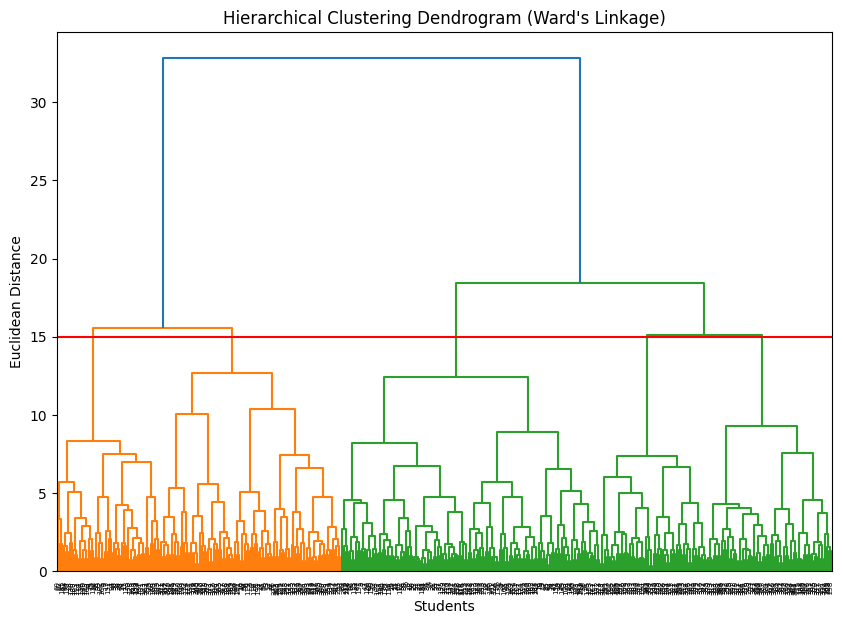


Hierarchical Clustering Sizes:
Cluster 0: [254 147] students
Cluster 1: [254 147] students


In [7]:
# Plot
plt.figure(figsize=(10, 7))
plt.title("Hierarchical Clustering Dendrogram (Ward's Linkage)")
plt.xlabel("Students")
plt.ylabel("Euclidean Distance")
# Calculate linkage
ward_linkage = sch.linkage(normalized_x, method='ward')
# Create dendogram
dendogram = sch.dendrogram(ward_linkage, truncate_mode='level', p=10)

cut_distance = 15

plt.axhline(y=cut_distance, color='r')
plt.show()

# Chosen number of cluster is 2
chosen_k = 2
# Creates clusters
agglo_cluster = AgglomerativeClustering(n_clusters=chosen_k, metric='euclidean', linkage='ward')
agglo_labels = agglo_cluster.fit_predict(normalized_x)

#Print clusters
agglo_unique, agglo_counts = np.unique(agglo_labels, return_counts=True)
print("\nHierarchical Clustering Sizes:")
for cluster_id, count in zip(agglo_unique, agglo_counts):
    print(f"Cluster {cluster_id}: {agglo_counts} students")


Quality: 
The y-axis represents the Euclidean distance, meaning the distance between each clusters. The distance represents the similarity between the clusters. For instance, the tall vertical drop in the graph represents the dissimilarity of the clusters. The dendogram suggested number of clusters agrees with the elbow method result, that the split of clusters should be 2. 

## 3.2 Linkage Comparison

The code below will run the agglomerative clustering with different linkage criteria. It will then compare each method.

Cluster sizes at K=2 for different linkages:

Single: Cluster 0: 400, Cluster 1: 1
Complete: Cluster 0: 251, Cluster 1: 150
Average: Cluster 0: 400, Cluster 1: 1
Ward: Cluster 0: 254, Cluster 1: 147


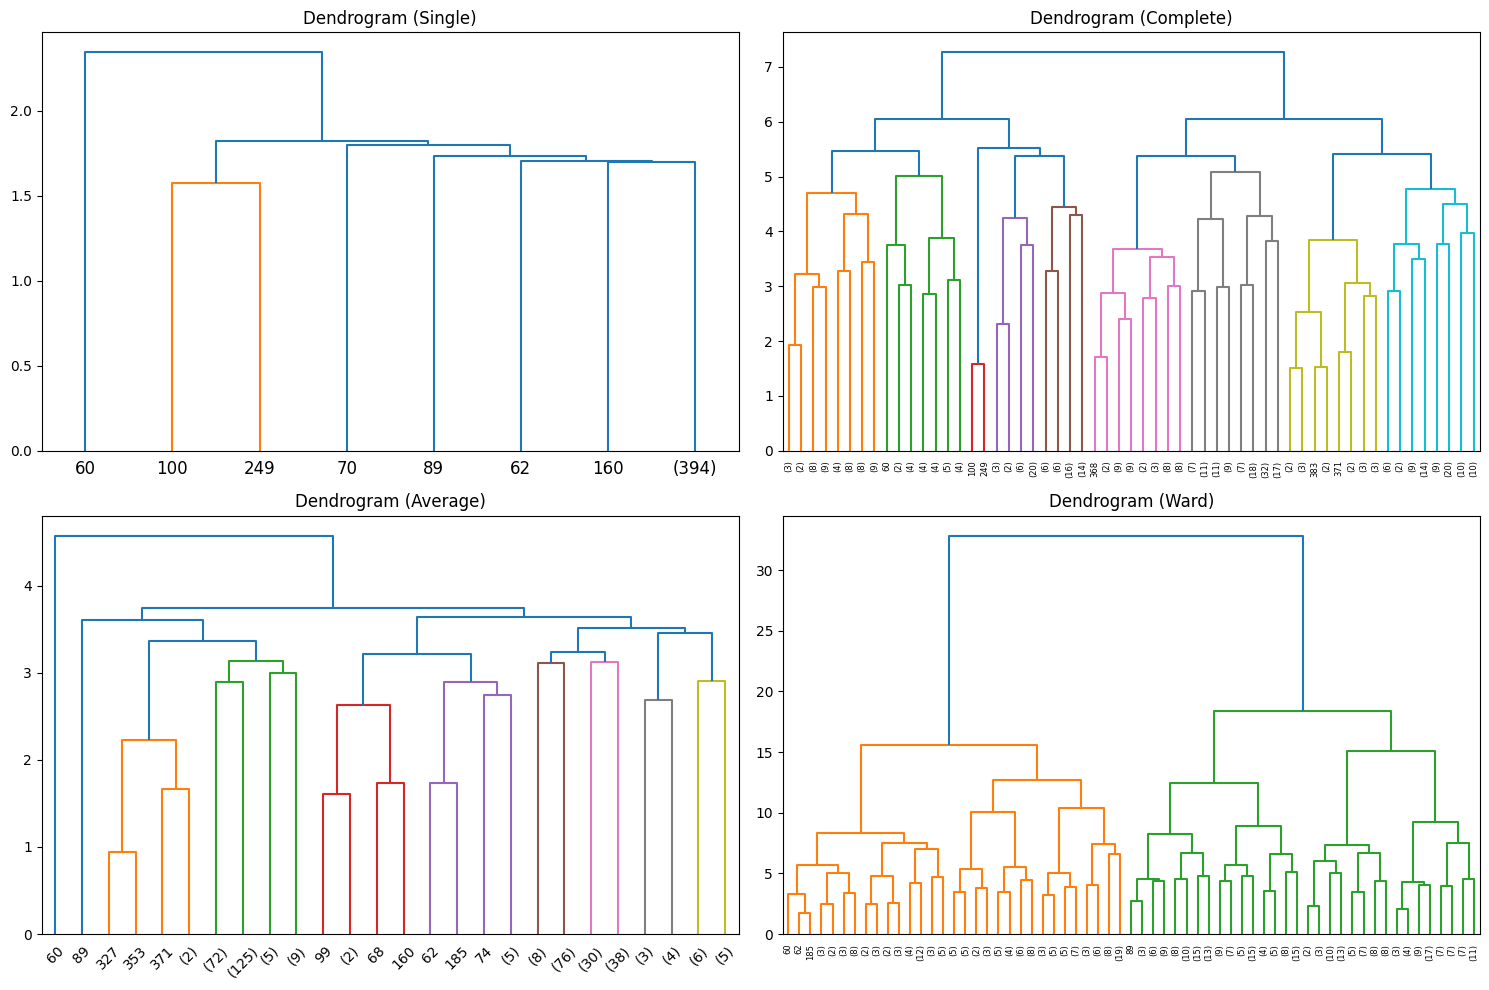

In [8]:
linkage_methods = ['single', 'complete', 'average', 'ward']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes = axes.flatten()

print("Cluster sizes at K=2 for different linkages:\n")

for i, method in enumerate(linkage_methods):
    # 1. Calculate linkage
    Z = sch.linkage(normalized_x, method=method)
    
    # 2. Assign clusters at K=2 and print sizes
    hc_method = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage=method)
    temp_labels = hc_method.fit_predict(normalized_x)
    unique, counts = np.unique(temp_labels, return_counts=True)
    print(f"{method.capitalize()}: Cluster 0: {counts[0]}, Cluster 1: {counts[1] if len(counts) > 1 else 0}")
    
    # 3. Plot dendrograms
    axes[i].set_title(f'Dendrogram ({method.capitalize()})')
    sch.dendrogram(Z, ax=axes[i], truncate_mode='level', p=5) # Truncated to avoid overcrowding

plt.tight_layout()
plt.show()

Quality:
Single linkage results in different results from Ward's linkage because 

# 4. DBSCAN

## 4.1 Core, Border, and Noise Points

Number of clusters found: 2
Number of noise points: 389

Cluster Sizes:
Noise (-1): 389 students
Cluster 0: 5 students
Cluster 1: 7 students

Student IDs classified as noise:
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 204 2

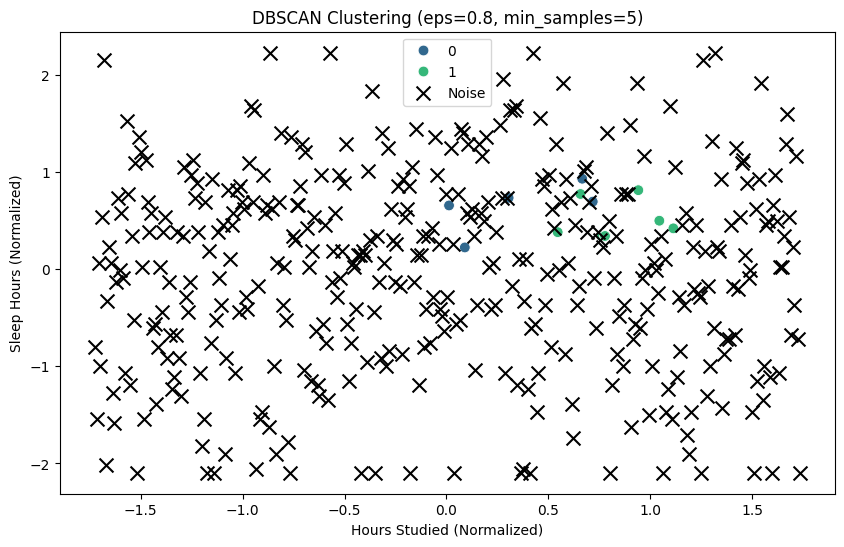

In [9]:
# Initial DBScan
dbscan = DBSCAN(eps=0.8, min_samples=5)
db_labels = dbscan.fit_predict(normalized_x)

# Report clusters
unique_labels = set(db_labels)
n_clusters = len(unique_labels) - (1 if -1 in db_labels else 0)
# Report noise
n_noise = list(db_labels).count(-1)

# Print clusters
print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise}")

db_unique, db_counts = np.unique(db_labels, return_counts=True)
print("\nCluster Sizes:")
for label, count in zip(db_unique, db_counts):
    if label == -1:
        print(f"Noise (-1): {count} students")
    else:
        print(f"Cluster {label}: {count} students")

# Student IDs for noise points
noise_student_ids = train.iloc[db_labels == -1]['student_id'].values
print("\nStudent IDs classified as noise:")
print(noise_student_ids)

# Plot Scatter plot
plt.figure(figsize=(10, 6))

# Plot the clustered points
mask_clusters = (db_labels != -1)
sns.scatterplot(
    x=normalized_x[mask_clusters, 0], # Index 0: hours_studied Z-score
    y=normalized_x[mask_clusters, 1], # Index 1: sleep_hours Z-score
    hue=db_labels[mask_clusters], 
    palette='viridis', 
    s=60
)

# Plot the noise points distinctly
mask_noise = (db_labels == -1)
plt.scatter(
    normalized_x[mask_noise, 0], 
    normalized_x[mask_noise, 1], 
    c='black', 
    marker='x', 
    s=100, 
    label='Noise'
)
plt.title('DBSCAN Clustering (eps=0.8, min_samples=5)')
plt.xlabel('Hours Studied (Normalized)')
plt.ylabel('Sleep Hours (Normalized)')
plt.legend()
plt.show()



Quality:
The three noise points that are going to be analyzed are students 1, 2, and 6. Students 1 and 2 had low study hours and average sleep hours, their attendance rate was average and their previous exam score was low. DBSCAN probably selected them as outliers because low hours studied and low prevous exam score. More than likely they are boundary students. In contrast, student 6 only had a low sleep score, with all the other features being high. The anomaly type that these points most resemble a collective anomaly. Individually, these points do not seem strange but together do form a bigger picture. 

## 4.2 Parameter Tuning

The code below will test different parameters on DBSCAN.

,eps,Clusters,Noise Points,Largest Cluster Size
0,0.5,0,401,0
1,0.8,2,389,7
2,1.0,5,320,54
3,1.5,2,40,355
4,3.0,1,0,401


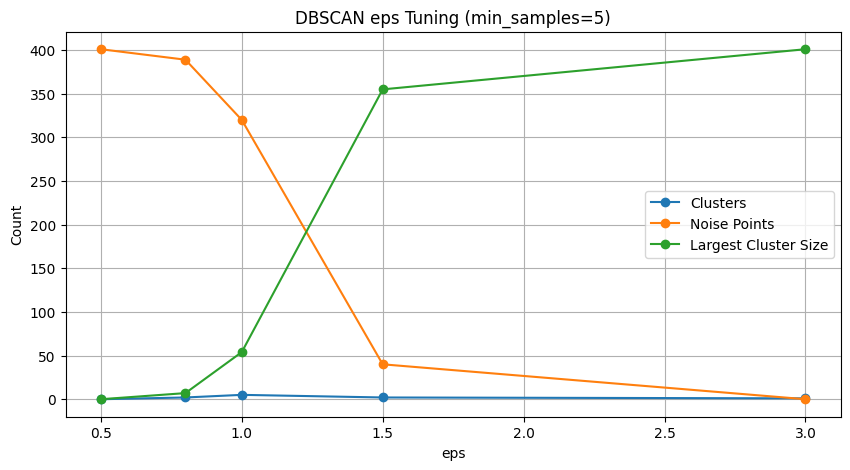

In [10]:
eps_values = [0.5, 0.8, 1.0, 1.5, 3.0]
min_samples = 5
results = []

# Goes through each eps value for DBSCAN
for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(normalized_x)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    # Calculate the size of the largest cluster
    if n_clusters > 0:
        largest_cluster = max([list(labels).count(lbl) for lbl in set(labels) if lbl != -1])
    else:
        largest_cluster = 0
        
    results.append({
        'eps': eps, 
        'Clusters': n_clusters, 
        'Noise Points': n_noise, 
        'Largest Cluster Size': largest_cluster
    })

# Create and display summary table
results_df = pd.DataFrame(results)
display(results_df)

# Plot the tradeoffs
results_df.plot(x='eps', y=['Clusters', 'Noise Points', 'Largest Cluster Size'], marker='o', figsize=(10,5))
plt.title('DBSCAN eps Tuning (min_samples=5)')
plt.ylabel('Count')
plt.grid(True)
plt.show()

Quality: 
When EPS increases it leads to larger clusters, and a reduction in noise points. Therefore, an overly large EPS could lead to overfitting. Once EPS is very small it leads small cluster sizes and and huge amount of noise points. This result could be intepreted as underfitting within the model. Experimenting with different eps values lead to more dramatic results. What this means is that the results increased the largest cluster size at a much higher rate at both min_samples = 3 and 10. Not specifying k-means is a disadvantage for this dataset because the model is more likely to group up students into one large group with a small amount of noise points. The k means models did not run into these issues.

# 5. Method Comparison

,Method,# Clusters,Noise Points,Largest Cluster,Smallest Cluster
0,K-Means (K=2),2,N/A,235,166
1,Hierarchical (Ward),2,N/A,254,147
2,DBSCAN (eps=0.8),2,389,7,5


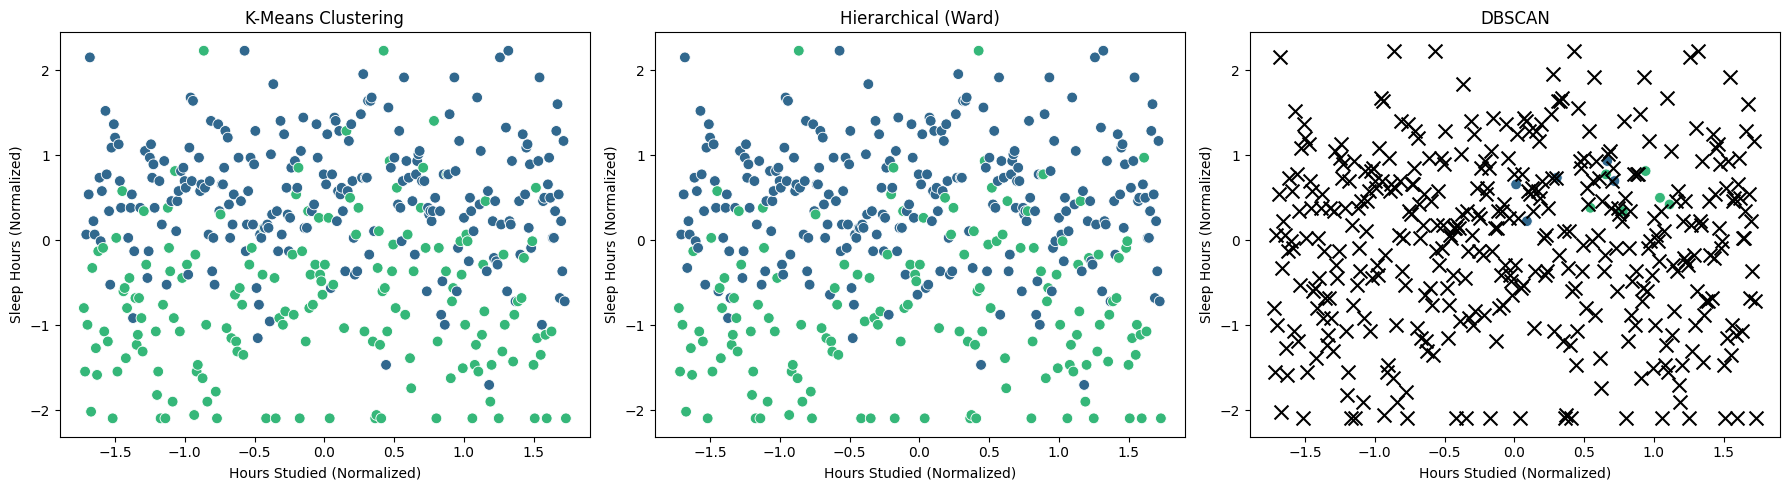

In [11]:
# Recalculates cluster since previous iterations were overwritten
def get_cluster_stats(labels_array, method_name, has_noise=False):
    # Calculate number of valid clusters (ignoring -1)
    n_clusters = len(set(labels_array)) - (1 if has_noise and -1 in labels_array else 0)
    # Count noise points
    n_noise = list(labels_array).count(-1) if has_noise else "N/A"
    
    # Calculate largest and smallest cluster sizes
    valid_labels = [l for l in labels_array if l != -1]
    if valid_labels:
        counts = [valid_labels.count(l) for l in set(valid_labels)]
        largest = max(counts)
        smallest = min(counts)
    else:
        largest, smallest = 0, 0
        
    return {"Method": method_name, "# Clusters": n_clusters, "Noise Points": n_noise, 
            "Largest Cluster": largest, "Smallest Cluster": smallest}

# Puts previous data into the table
table_data = [
    get_cluster_stats(kmeans_labels, "K-Means (K=2)", has_noise=False),
    get_cluster_stats(agglo_labels, "Hierarchical (Ward)", has_noise=False),
    get_cluster_stats(db_labels, "DBSCAN (eps=0.8)", has_noise=True)
]

comparison_df = pd.DataFrame(table_data)
display(comparison_df)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))


feature_x = 0 
feature_y = 1 

titles = ['K-Means Clustering', 'Hierarchical (Ward)', 'DBSCAN']
label_sets = [kmeans_labels, agglo_labels, db_labels]

# Plots graphs together
for i, ax in enumerate(axes):
    lbls = label_sets[i]
    
    # Plot the standard clusters
    mask_clusters = (lbls != -1)
    
    sns.scatterplot(x=normalized_x[mask_clusters, feature_x], 
                    y=normalized_x[mask_clusters, feature_y], 
                    hue=lbls[mask_clusters], palette='viridis', s=60, ax=ax, legend=False)
    
    # Plot the noise points distinctly for DBSCAN
    if -1 in lbls:
        mask_noise = (lbls == -1)
        ax.scatter(normalized_x[mask_noise, feature_x], normalized_x[mask_noise, feature_y], 
                   c='black', marker='x', s=100, label='Noise')
        
    ax.set_title(titles[i])
    ax.set_xlabel('Hours Studied (Normalized)')
    ax.set_ylabel('Sleep Hours (Normalized)')

plt.tight_layout()
plt.show()

Quality:
The method that I think would work best for the dataset would be between the k means clustering model or the hierarchical. If I had to choose one, I would use k means clustering. The fundamental differences between each one of the models is that K-means lets you preset the amount of clusters you want to have. This way it can be more specialized. Hierarchical clustering uses a hierarchy, meaning that a dendrogram is used to separate the clusters that are tightly knitted. DBSCAN finds arbitrary-shaped clusters and noise, which during this project led to less accurate result. Depending on the epsilon, the model could easily switch to and underfitting to and overfitting model. The method that I would recommend to a university administrator would be the kmeans clustering method because it allows for more specialization, meaning that high risk students could be easily identifed with 3 clusters, where one would represent the students with the least amount of effort.

# 6. Cluster vs. Ground Truth Comparison

The code below will merge the actual data results compared to the trained models.

Cross-Tabulation: Cluster vs. True Pass/Fail



True Label (Passed),0,1
K-Means Cluster,,
0,32,201
1,141,24



Alignment Percentage: 85.93%


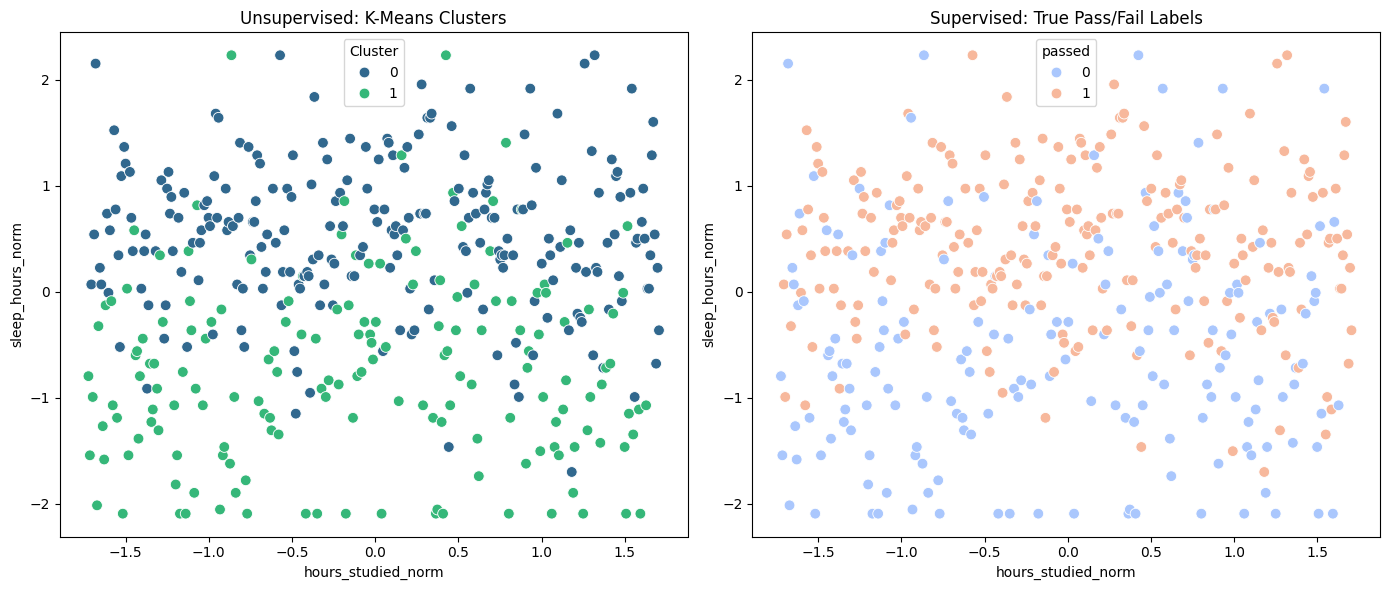

In [12]:
# Create a clean copy of your original dataset to hold the labels
results_df = train.copy()
results_df['Cluster'] = kmeans_labels

# Normalize using scaler since it will be much easier to print


# Merge the unsupervised clusters with the true pass/fail labels
results_df['Cluster'] = kmeans_labels
results_df['hours_studied_norm'] = normalized_x[:, 0] # Index 0
results_df['sleep_hours_norm'] = normalized_x[:, 1]   # Index 1
merged_df = pd.merge(results_df, test, on='student_id')

# Create Cross-Tabulation
print("Cross-Tabulation: Cluster vs. True Pass/Fail\n")
crosstab = pd.crosstab(merged_df['Cluster'], merged_df['passed'], 
                       rownames=['K-Means Cluster'], colnames=['True Label (Passed)'])
display(crosstab)


# 5. Compute Alignment Percentage
# We check if Cluster 0 = Fail (0) or if Cluster 0 = Pass (1)
match_1 = (merged_df['Cluster'] == merged_df['passed']).sum()
match_2 = (merged_df['Cluster'] != merged_df['passed']).sum()

alignment_percentage = (max(match_1, match_2) / len(merged_df)) * 100
print(f"\nAlignment Percentage: {alignment_percentage:.2f}%")

# 6. Final Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=merged_df['hours_studied_norm'], y=merged_df['sleep_hours_norm'], 
                hue=merged_df['Cluster'], palette='viridis', s=60, ax=axes[0])
axes[0].set_title('Unsupervised: K-Means Clusters')

sns.scatterplot(x=merged_df['hours_studied_norm'], y=merged_df['sleep_hours_norm'], 
                hue=merged_df['passed'], palette='coolwarm', s=60, ax=axes[1])
axes[1].set_title('Supervised: True Pass/Fail Labels')

plt.tight_layout()
plt.show()

Quality:
The K Means method was able to discover the different groups due to their similarity in the selected features. Students who had high previous exam score, high sleep and high study time were grouped together, students who were the opposite were also grouped together. The groups align pretty well with alignment percentage of 85%. A student might be in the wrong cluster due to real world factors, such as missing an exam or test anxiety. Unsupervised learning could be preferred in large datasets, where not all the data is complete but patterns could still constructed from the data.

# 7. Summary & Reflection

The clustering method that worked best on this dataset was the K Means method because it was able to successfully create two clusters. One cluster had students that high previous performance and the other cluster had low previous performance. However, the hierarchical clustering achieved similar results, as it was able to create two clusters that represented two types of students. I think that K Means method has a higher chance of being more useful in the real world. As discussed earlier, a university administrator would find k means much more useful, as they can create several clusters of different types of students. Therefore, for real world applications using this dataset, K Means is higher performing and more mutable. The worst performing clustering method was DBSCAN. This poor performance is due to it classifying a lot of data as noise, which led to less accurate results. For this reason, it is my last choice to use in a real world application. The most surprising thing when comparing the clusters to ground truth was the very accurate results the unsupervised model was able to create. My model was able to achieve an alignment percentage of 85%. The K means model was able to group up students with similar features and it was able to somewhat differentiate two groups, which aligns with the pass rate of the actual truth. Implementing K Means from scratch deepened my understanding of the clustering method because it helped me apply the functions, concepts and math that was discussed in the lecture, and turn it into actual code that produces accurate results. A real world application where unsupervised learning could be helpful is identifying students who could need extra tutoring or class time. Another real world application would be analyzing consumers, and their likelihood of buying certain products. If I had more time with the project, an additional analysis I would do is comparing the DBSCAN and hierarchical clustering to the real data.